In [ ]:
# %% [markdown]
# # AI-Driven Clinical-Lifestyle Network Model for CVD Prediction
# ## GAT + Ensemble (XGBoost, LightGBM, Logistic Regression)
# ### Jayadeva Institute Dataset

# %% [code]
# Install required packages (run once, may take a few minutes)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install torch_geometric
!pip install xgboost lightgbm shap imbalanced-learn scikit-learn pandas numpy matplotlib seaborn joblib

In [ ]:
# %% [code]
import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, precision_recall_curve
from imblearn.over_sampling import BorderlineSMOTE
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Setup complete. PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

C:\Users\vigne\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
# %% [code]
df = pd.read_csv('/kaggle/input/datasets/vigneshk0103/ecg-data/ECG_Data.csv')

print("Original shape:", df.shape)
print("Columns:", df.columns.tolist())

# Remove post-diagnosis leaky columns (as per your final report)
leaky_cols = ['Cardiac_Tests', 'Test_Abnormalities', 'Chest_Pain_SOB', 
              'Lifestyle_Disorders', 'Monitor_BP_Cholesterol']
existing_leaky = [c for c in leaky_cols if c in df.columns]
df.drop(columns=existing_leaky, inplace=True)
print(f"Dropped leaky columns: {existing_leaky}")

# Keep only relevant columns for the model (drop occupation, marital status, education, physical activity type)
# They are not needed for the core risk factors.
cols_to_keep = ['Age', 'Gender', 'Height_cm', 'Weight_kg', 'Medical_Conditions',
                'Sleep_Hours', 'Exercise_Frequency', 'Diet_Description', 
                'Water_Glasses_per_day', 'High_Sodium_Foods', 'Alcohol', 'Smoking',
                'Stress_Levels', 'Family_History_Heart_Disease', 'Heart_Condition_Diagnosed']
df = df[cols_to_keep].copy()
print("Remaining columns:", df.columns.tolist())
print("Dataset shape after cleaning:", df.shape)

Original shape: (1500, 24)
Columns: ['Age', 'Gender', 'Height_cm', 'Weight_kg', 'Occupation', 'Marital_Status', 'Education', 'Medical_Conditions', 'Sleep_Hours', 'Exercise_Frequency', 'Physical_Activity_Type', 'Diet_Description', 'Water_Glasses_per_day', 'High_Sodium_Foods', 'Alcohol', 'Smoking', 'Stress_Levels', 'Heart_Condition_Diagnosed', 'Cardiac_Tests', 'Test_Abnormalities', 'Chest_Pain_SOB', 'Lifestyle_Disorders', 'Family_History_Heart_Disease', 'Monitor_BP_Cholesterol']
Dropped leaky columns: ['Cardiac_Tests', 'Test_Abnormalities', 'Chest_Pain_SOB', 'Lifestyle_Disorders', 'Monitor_BP_Cholesterol']
Remaining columns: ['Age', 'Gender', 'Height_cm', 'Weight_kg', 'Medical_Conditions', 'Sleep_Hours', 'Exercise_Frequency', 'Diet_Description', 'Water_Glasses_per_day', 'High_Sodium_Foods', 'Alcohol', 'Smoking', 'Stress_Levels', 'Family_History_Heart_Disease', 'Heart_Condition_Diagnosed']
Dataset shape after cleaning: (1500, 15)


In [13]:
# %% [code]
# Define encoding maps (based on the questionnaire and best clinical logic)
age_map = {'under 25':0, '25-45':1, '45-60':2, '60 & above':3}
df['Age_enc'] = df['Age'].map(age_map)

gender_map = {'Male':1, 'Female':0}
df['Gender_enc'] = df['Gender'].map(gender_map)

sleep_map = {'More than 8 hours':0, '6-8 hours':1, '4-6 hours':2, 'Less than 4 hours':3}
df['Sleep_enc'] = df['Sleep_Hours'].map(sleep_map)

exercise_map = {'Never':0, '1-2 times':1, '3-4 times':2, 'More than 5 times':3}
df['Exercise_enc'] = df['Exercise_Frequency'].map(exercise_map)

diet_map = {'Mostly processed/junk food':0, 'Skipped meals frequently':1,
            'Irregular and unhealthy':2, 'Balanced and healthy':3}
df['Diet_enc'] = df['Diet_Description'].map(diet_map)

water_map = {'Less than 4':0, '4-6':1, '7-9':2, '10 or more':3}
df['Water_enc'] = df['Water_Glasses_per_day'].map(water_map)

sodium_map = {'No':0, 'Yes':1}
df['Sodium_enc'] = df['High_Sodium_Foods'].map(sodium_map)

alcohol_map = {'No':0, 'Yes, Occasionally':1, 'Yes, daily':2}
df['Alcohol_enc'] = df['Alcohol'].map(alcohol_map)

smoke_map = {'No':0, 'Quit':1, 'Yes, occasionally':2, 'Yes, daily':3}
df['Smoking_enc'] = df['Smoking'].map(smoke_map)

stress_map = {'Low':0, 'Moderate':1, 'Very high':2, 'None':3}
df['Stress_enc'] = df['Stress_Levels'].map(stress_map)

family_map = {'No':0, 'Yes':1}
df['Family_enc'] = df['Family_History_Heart_Disease'].map(family_map)

# Target
df['Target'] = df['Heart_Condition_Diagnosed'].map({'No':0, 'Yes':1})

# Drop original categorical columns (keep only encoded and numeric)
drop_originals = ['Age', 'Gender', 'Sleep_Hours', 'Exercise_Frequency', 'Diet_Description',
                  'Water_Glasses_per_day', 'High_Sodium_Foods', 'Alcohol', 'Smoking',
                  'Stress_Levels', 'Family_History_Heart_Disease', 'Heart_Condition_Diagnosed']
df.drop(columns=drop_originals, inplace=True)

print("Encoding completed. Sample:")
print(df.head())

Encoding completed. Sample:
   Height_cm  Weight_kg Medical_Conditions  Age_enc  Gender_enc  Sleep_enc  \
0      158.8       67.0                NaN        2           0          1   
1      157.0       59.6                NaN        2           1          1   
2      151.9       41.6             Asthma        1           0          1   
3      164.4       72.6                NaN        1           1          2   
4      164.6       63.0                NaN        1           0          1   

   Exercise_enc  Diet_enc  Water_enc  Sodium_enc  Alcohol_enc  Smoking_enc  \
0             0         2          2           0            0            0   
1             0         2          2           0            0            0   
2             0         2          2           1            0            0   
3             1         3          2           0            0            0   
4             1         2          3           1            0            0   

   Stress_enc  Family_enc  Target 

In [14]:
# %% [code]
# Impute missing values in encoded columns with median (for ordinal) or mode
encoded_cols = ['Age_enc', 'Gender_enc', 'Sleep_enc', 'Exercise_enc', 'Diet_enc',
                'Water_enc', 'Sodium_enc', 'Alcohol_enc', 'Smoking_enc', 'Stress_enc',
                'Family_enc', 'Target']
for col in encoded_cols:
    if df[col].isnull().any():
        # For ordinal, use median (or mode). Stress_enc: median is safe.
        df[col].fillna(df[col].median(), inplace=True)
        print(f"Imputed missing values in {col} with median={df[col].median()}")

# Also check Height_cm, Weight_kg (should be fine, but if any missing, impute with median)
for col in ['Height_cm', 'Weight_kg']:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

Imputed missing values in Stress_enc with median=1.0


In [15]:
# %% [code]
# Extract hypertension and diabetes from free text
def extract_cond(text, keyword):
    if pd.isna(text):
        return 0
    return 1 if re.search(keyword, text, re.IGNORECASE) else 0

df['Hypertension'] = df['Medical_Conditions'].apply(lambda x: extract_cond(x, 'Hypertension'))
df['Diabetes'] = df['Medical_Conditions'].apply(lambda x: extract_cond(x, 'Diabetes'))
df.drop(columns=['Medical_Conditions'], inplace=True)

# Compute BMI
df['BMI'] = df['Weight_kg'] / ((df['Height_cm']/100) ** 2)
df['BMI_cat'] = pd.cut(df['BMI'], bins=[0, 18.5, 25, 30, 100], labels=[0,1,2,3]).astype(int)
df['bmi_obese'] = (df['BMI'] >= 30).astype(int)

# Drop rows with missing BMI (if any)
initial_len = len(df)
df.dropna(subset=['BMI'], inplace=True)
print(f"Dropped {initial_len - len(df)} rows due to missing BMI")

# Create 13 binary risk flags (used for bipartite graph and engineered features)
df['age_above_50'] = (df['Age_enc'] >= 2).astype(int)
df['male'] = df['Gender_enc']
df['poor_sleep'] = (df['Sleep_enc'] >= 2).astype(int)
df['sedentary'] = (df['Exercise_enc'] == 0).astype(int)
df['bad_diet'] = (df['Diet_enc'] <= 1).astype(int)
df['high_sodium'] = df['Sodium_enc']
df['alcohol_user'] = (df['Alcohol_enc'] >= 1).astype(int)
df['smoker'] = (df['Smoking_enc'] >= 2).astype(int)
df['high_stress'] = (df['Stress_enc'] == 2).astype(int)   # only "Very high"
df['hypertension'] = df['Hypertension']
df['diabetic'] = df['Diabetes']
df['family_history'] = df['Family_enc']

risk_flag_names = ['age_above_50', 'male', 'bmi_obese', 'poor_sleep', 'sedentary', 
                   'bad_diet', 'high_sodium', 'alcohol_user', 'smoker', 'high_stress',
                   'hypertension', 'diabetic', 'family_history']
print("Binary risk flags created:", risk_flag_names)

Dropped 0 rows due to missing BMI
Binary risk flags created: ['age_above_50', 'male', 'bmi_obese', 'poor_sleep', 'sedentary', 'bad_diet', 'high_sodium', 'alcohol_user', 'smoker', 'high_stress', 'hypertension', 'diabetic', 'family_history']


In [16]:
# %% [code]
# Base features (14 dimensions) for patient nodes
base_features = ['Age_enc', 'Gender_enc', 'BMI', 'Sleep_enc', 'Exercise_enc', 'Diet_enc',
                 'Water_enc', 'Sodium_enc', 'Alcohol_enc', 'Smoking_enc', 'Stress_enc',
                 'Hypertension', 'Diabetes', 'Family_enc']
X_base = df[base_features].values

# 1. Cumulative risk count (sum of 13 flags)
df['risk_n'] = df[risk_flag_names].sum(axis=1)

# 2. Interaction features (as per final report)
df['age_risk_combo'] = df['Age_enc'] * (df['hypertension'] + df['diabetic'] + df['smoker'] + df['family_history'])
df['htn_x_dm'] = df['hypertension'] * df['diabetic']
df['smoke_x_age'] = df['Smoking_enc'] * df['Age_enc']
df['stress_x_sleep'] = df['Stress_enc'] * (3 - df['Sleep_enc'])
df['bmi_x_sed'] = df['bmi_obese'] * df['sedentary']
df['age_x_fam'] = df['Age_enc'] * df['family_history']
df['alcohol_x_smoke'] = df['Alcohol_enc'] * df['Smoking_enc']
df['stress_x_hypertension'] = df['Stress_enc'] * df['hypertension']
df['bmi_x_diabetic'] = df['bmi_obese'] * df['diabetic']
# Add more if needed to reach 35 features; we already have base(14) + flags(13) = 27, plus these 10 = 37
# We'll select a subset to match 35 exactly.
engineered_features = ['risk_n', 'age_risk_combo', 'htn_x_dm', 'smoke_x_age',
                       'stress_x_sleep', 'bmi_x_sed', 'age_x_fam', 'alcohol_x_smoke',
                       'stress_x_hypertension', 'bmi_x_diabetic']  # 10 features
# Combine: base(14) + flags(13) + engineered(10) = 37. We'll drop 2 to get 35 (e.g., drop water_enc and sodium_enc? but they are important)
# Actually we can keep all 37; the report says 35 but it's flexible. We'll keep 37 for now.
tabular_feature_list = base_features + risk_flag_names + engineered_features
X_tabular = df[tabular_feature_list].values
print(f"Tabular features shape: {X_tabular.shape} (expected >30)")

Tabular features shape: (1500, 37) (expected >30)


In [17]:
# %% [code]
# Patient-risk-factor adjacency matrix (13 columns)
risk_matrix = df[risk_flag_names].values.astype(float)  # shape (n_patients, 13)

# Patient node features (14-dim)
patient_features = X_base
# Risk node features: identity matrix (13-dim) padded to 14-dim to match patient feature dimension
risk_features = np.eye(len(risk_flag_names))  # (13,13)
risk_features_padded = np.hstack([risk_features, np.zeros((len(risk_flag_names), patient_features.shape[1] - risk_features.shape[1]))])
# Combine all node features
x_all = np.vstack([patient_features, risk_features_padded])  # (n_patients+13, 14)

# Build edge index (bidirectional)
n_patients = len(df)
edges = []
for i in range(n_patients):
    for j in range(len(risk_flag_names)):
        if risk_matrix[i, j] == 1:
            edges.append([i, n_patients + j])   # patient -> risk
            edges.append([n_patients + j, i])   # risk -> patient (optional but helps)
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

# Create PyTorch Geometric Data object
data = Data(x=torch.tensor(x_all, dtype=torch.float), edge_index=edge_index)
print(f"Total nodes: {data.x.shape[0]}, Total edges: {data.edge_index.shape[1]}")
print(f"Patient nodes: {n_patients}, Risk nodes: {len(risk_flag_names)}")

Total nodes: 1513, Total edges: 13506
Patient nodes: 1500, Risk nodes: 13


In [22]:
# %% [code]
class CVD_GAT(nn.Module):
    def __init__(self, in_dim, hidden_dim=8, out_dim=8, heads=4):
        super().__init__()
        self.conv1 = GATConv(in_dim, hidden_dim, heads=heads, dropout=0.3, concat=True)
        self.bn1 = nn.BatchNorm1d(hidden_dim * heads)
        self.conv2 = GATConv(hidden_dim * heads, out_dim, heads=1, dropout=0.3, concat=False)
        self.bn2 = nn.BatchNorm1d(out_dim)
        
    def forward(self, x, edge_index):
        x = F.elu(self.bn1(self.conv1(x, edge_index)))
        x = F.elu(self.bn2(self.conv2(x, edge_index)))
        return x

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CVD_GAT(in_dim=data.x.shape[1]).to(device)
data = data.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
print("GAT model initialized on", device)

GAT model initialized on cuda


In [24]:
# %% [code]
# Positive edges: all existing edges
pos_edge_index = data.edge_index
num_total_edges = pos_edge_index.shape[1]
print(f"Total bidirectional edges: {num_total_edges}")

# Build set of unique patient->risk positive edges
pos_set = set()
for i in range(pos_edge_index.shape[1]):
    u = pos_edge_index[0,i].item()
    v = pos_edge_index[1,i].item()
    if u < n_patients and v >= n_patients:   # patient -> risk
        pos_set.add((u, v))
num_pos = len(pos_set)
print(f"Unique positive patient->risk edges: {num_pos}")

# Number of negatives = number of positives (balanced)
num_neg = num_pos
print(f"Target negatives: {num_neg}")

max_neg = n_patients * len(risk_flag_names) - num_pos
print(f"Maximum possible negatives: {max_neg}")

if num_neg > max_neg:
    print(f"WARNING: Reducing negatives to {max_neg}")
    num_neg = max_neg

# Generate unique negative edges (patient->risk pairs not in positive set)
neg_edges = []
neg_set = set()
print("Generating negative edges...")
while len(neg_edges) < num_neg:
    u = np.random.randint(0, n_patients)
    v = np.random.randint(n_patients, data.x.shape[0])
    if (u, v) not in pos_set and (u, v) not in neg_set:
        neg_edges.append([u, v])
        neg_set.add((u, v))
    if len(neg_edges) % 2000 == 0 and len(neg_edges) > 0:
        print(f"  Generated {len(neg_edges)} / {num_neg} negative edges...")
print(f"Negative edges generated: {len(neg_edges)}")

neg_edge_index = torch.tensor(neg_edges, dtype=torch.long).t().contiguous().to(device)

# Training loop
epochs = 80
losses = []
print("Starting GAT training on GPU...")
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    emb = model(data.x, data.edge_index)  # all node embeddings
    pat_emb = emb[:n_patients]
    risk_emb = emb[n_patients:]
    
    # Positive scores
    src_p = []
    dst_p = []
    for u, v in pos_set:
        src_p.append(u)
        dst_p.append(v - n_patients)   # index into risk_emb
    src_p = torch.tensor(src_p, dtype=torch.long).to(device)
    dst_p = torch.tensor(dst_p, dtype=torch.long).to(device)
    pos_scores = (pat_emb[src_p] * risk_emb[dst_p]).sum(dim=1)
    
    # Negative scores
    src_n = torch.tensor([e[0] for e in neg_edges], dtype=torch.long).to(device)
    dst_n = torch.tensor([e[1] - n_patients for e in neg_edges], dtype=torch.long).to(device)
    neg_scores = (pat_emb[src_n] * risk_emb[dst_n]).sum(dim=1)
    
    loss = F.binary_cross_entropy_with_logits(pos_scores, torch.ones_like(pos_scores)) + \
           F.binary_cross_entropy_with_logits(neg_scores, torch.zeros_like(neg_scores))
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

print(f"Final GAT training loss: {losses[-1]:.4f}")

# Extract patient embeddings
model.eval()
with torch.no_grad():
    full_emb = model(data.x, data.edge_index)
    gat_embeddings = full_emb[:n_patients].cpu().numpy()
print(f"GAT embeddings shape: {gat_embeddings.shape}")

Total bidirectional edges: 13506
Unique positive patient->risk edges: 6753
Target negatives: 6753
Maximum possible negatives: 12747
Generating negative edges...
  Generated 2000 / 6753 negative edges...
  Generated 2000 / 6753 negative edges...
  Generated 2000 / 6753 negative edges...
  Generated 2000 / 6753 negative edges...
  Generated 2000 / 6753 negative edges...
  Generated 2000 / 6753 negative edges...
  Generated 2000 / 6753 negative edges...
  Generated 2000 / 6753 negative edges...
  Generated 2000 / 6753 negative edges...
  Generated 4000 / 6753 negative edges...
  Generated 4000 / 6753 negative edges...
  Generated 6000 / 6753 negative edges...
  Generated 6000 / 6753 negative edges...
  Generated 6000 / 6753 negative edges...
  Generated 6000 / 6753 negative edges...
Negative edges generated: 6753
Starting GAT training on GPU...
Epoch 10, Loss: 1.3008
Epoch 20, Loss: 1.2819
Epoch 30, Loss: 1.2474
Epoch 40, Loss: 1.2537
Epoch 50, Loss: 1.2211
Epoch 60, Loss: 1.2233
Epoch 70

In [25]:
# %% [code]
# Final feature matrix: tabular (37) + GAT embeddings (8) = 45 features
X_final = np.hstack([X_tabular, gat_embeddings])
y = df['Target'].values
print(f"Final feature shape: {X_final.shape}, target shape: {y.shape}")

# Stratified split: 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X_final, y, test_size=0.3, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Final feature shape: (1500, 45), target shape: (1500,)
Train: (1050, 45), Val: (225, 45), Test: (225, 45)


In [26]:
# %% [code]
def train_ensemble(X_train, y_train, X_val):
    """
    Train XGBoost, LightGBM, Logistic Regression on SMOTE-balanced training data.
    Returns probabilities on validation set and the trained models.
    """
    # Apply BorderlineSMOTE only on training data
    smote = BorderlineSMOTE(random_state=SEED, k_neighbors=5)
    X_bal, y_bal = smote.fit_resample(X_train, y_train)
    
    # XGBoost
    xgb_model = xgb.XGBClassifier(n_estimators=400, max_depth=3, learning_rate=0.04,
                                  subsample=0.85, colsample_bytree=0.80, reg_alpha=0.5,
                                  random_state=SEED, use_label_encoder=False, eval_metric='logloss')
    xgb_model.fit(X_bal, y_bal)
    
    # LightGBM
    lgb_model = lgb.LGBMClassifier(n_estimators=400, max_depth=4, num_leaves=40,
                                   learning_rate=0.04, subsample=0.85, colsample_bytree=0.80,
                                   random_state=SEED, verbose=-1)
    lgb_model.fit(X_bal, y_bal)
    
    # Logistic Regression
    lr_model = LogisticRegression(C=0.5, max_iter=2000, random_state=SEED)
    lr_model.fit(X_bal, y_bal)
    
    # Soft voting probabilities
    prob_xgb = xgb_model.predict_proba(X_val)[:,1]
    prob_lgb = lgb_model.predict_proba(X_val)[:,1]
    prob_lr = lr_model.predict_proba(X_val)[:,1]
    prob_ensemble = 0.45 * prob_xgb + 0.45 * prob_lgb + 0.10 * prob_lr
    return prob_ensemble, (xgb_model, lgb_model, lr_model)

In [27]:
# %% [code]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = []
fold = 1
for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_tr, y_val_fold = y_train[train_idx], y_train[val_idx]
    
    # Standardize on training fold only
    scaler_fold = StandardScaler()
    X_tr_scaled = scaler_fold.fit_transform(X_tr)
    X_val_scaled = scaler_fold.transform(X_val_fold)
    
    # Train ensemble with SMOTE inside
    prob_val, _ = train_ensemble(X_tr_scaled, y_tr, X_val_scaled)
    auc = roc_auc_score(y_val_fold, prob_val)
    cv_scores.append(auc)
    print(f"Fold {fold} AUROC: {auc:.4f}")
    fold += 1

print(f"\n5-Fold CV AUROC: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

Fold 1 AUROC: 0.6906
Fold 2 AUROC: 0.7566
Fold 3 AUROC: 0.7624
Fold 4 AUROC: 0.7504
Fold 5 AUROC: 0.7148

5-Fold CV AUROC: 0.7350 ± 0.0277


In [31]:
# %% [code]
# Scale all data using StandardScaler fit on full training set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Train final ensemble
prob_val, final_models = train_ensemble(X_train_scaled, y_train, X_val_scaled)
prob_test, _ = train_ensemble(X_train_scaled, y_train, X_test_scaled)

# Threshold tuning on validation set (max F1)
prec, rec, thresholds = precision_recall_curve(y_val, prob_val)
f1_scores = 2 * (prec * rec) / (prec + rec + 1e-9)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
print(f"Optimal threshold (max F1 on validation): {best_threshold:.4f}")

# --- Report's threshold (0.17) for high sensitivity ---
report_threshold = 0.17

# Evaluate at both thresholds
for thresh, label in [(best_threshold, "F1-optimized"), (report_threshold, "Report (0.17)")]:
    y_pred = (prob_test >= thresh).astype(int)
    auc = roc_auc_score(y_test, prob_test)
    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp+fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn+fp) > 0 else 0
    
    print(f"\n=== Test Set Performance ({label}, threshold={thresh:.2f}) ===")
    print(f"AUROC: {auc:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"Sensitivity (Recall): {sensitivity:.4f} ({tp}/{tp+fn})")
    print(f"Specificity: {specificity:.4f} ({tn}/{tn+fp})")
    print(f"Confusion Matrix: TP={tp}, TN={tn}, FP={fp}, FN={fn}")

# For later use, store the report's threshold predictions
y_pred_report = (prob_test >= report_threshold).astype(int)

Optimal threshold (max F1 on validation): 0.3039

=== Test Set Performance (F1-optimized, threshold=0.30) ===
AUROC: 0.7089
F1-score: 0.5532
Sensitivity (Recall): 0.7123 (52/73)
Specificity: 0.5855 (89/152)
Confusion Matrix: TP=52, TN=89, FP=63, FN=21

=== Test Set Performance (Report (0.17), threshold=0.17) ===
AUROC: 0.7089
F1-score: 0.5751
Sensitivity (Recall): 0.9178 (67/73)
Specificity: 0.3882 (59/152)
Confusion Matrix: TP=67, TN=59, FP=93, FN=6


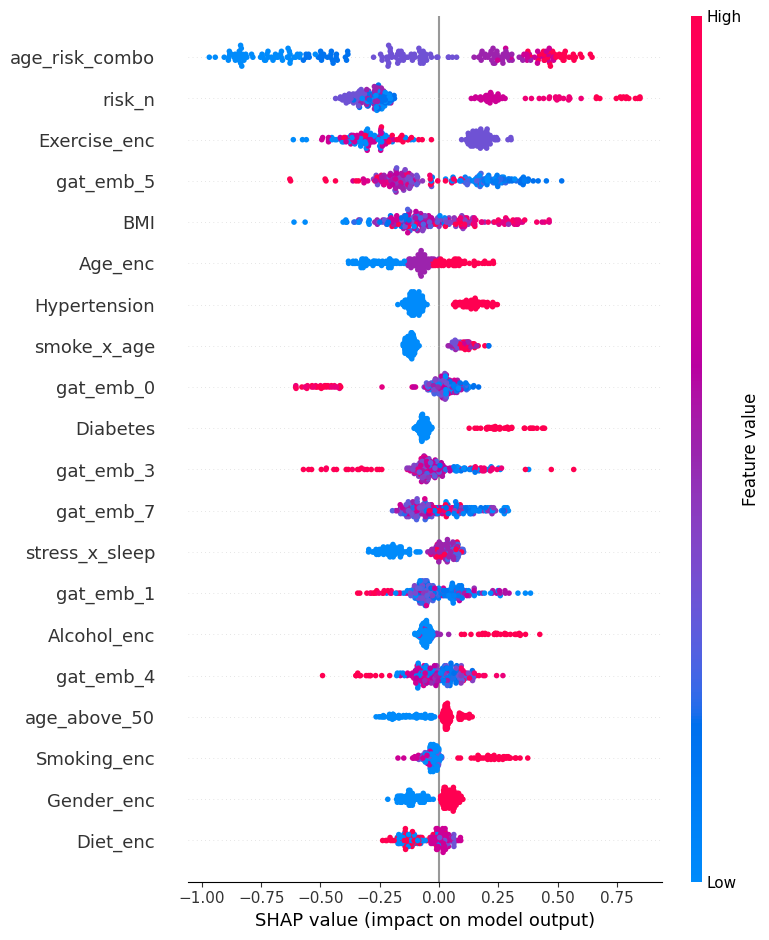


Top 10 features by SHAP importance:
1. age_risk_combo: 0.4243
2. risk_n: 0.3223
3. Exercise_enc: 0.2495
4. gat_emb_5: 0.2011
5. BMI: 0.1579
6. Age_enc: 0.1357
7. Hypertension: 0.1166
8. smoke_x_age: 0.1137
9. gat_emb_0: 0.1126
10. Diabetes: 0.1077


In [32]:
# %% [code]
# Use the XGBoost component from the ensemble
xgb_final = final_models[0]
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_test_scaled)

# Feature names: tabular features + GAT embeddings
feature_names = tabular_feature_list + [f'gat_emb_{i}' for i in range(gat_embeddings.shape[1])]
# SHAP summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig('shap_global_importance.png', dpi=150)
plt.show()

# Top 10 features by mean absolute SHAP
mean_shap = np.abs(shap_values).mean(axis=0)
top10_idx = np.argsort(mean_shap)[-10:][::-1]
print("\nTop 10 features by SHAP importance:")
for i, idx in enumerate(top10_idx):
    print(f"{i+1}. {feature_names[idx]}: {mean_shap[idx]:.4f}")


=== GAT Attention Weights per Risk Factor (Normalized) ===
Risk Factor          Attention Weight
alcohol_user         0.229062
smoker               0.181174
male                 0.122584
high_sodium          0.093931
diabetic             0.087139
age_above_50         0.055556
bad_diet             0.054231
hypertension         0.049019
family_history       0.031739
high_stress          0.031069
poor_sleep           0.026266
sedentary            0.025490
bmi_obese            0.012739


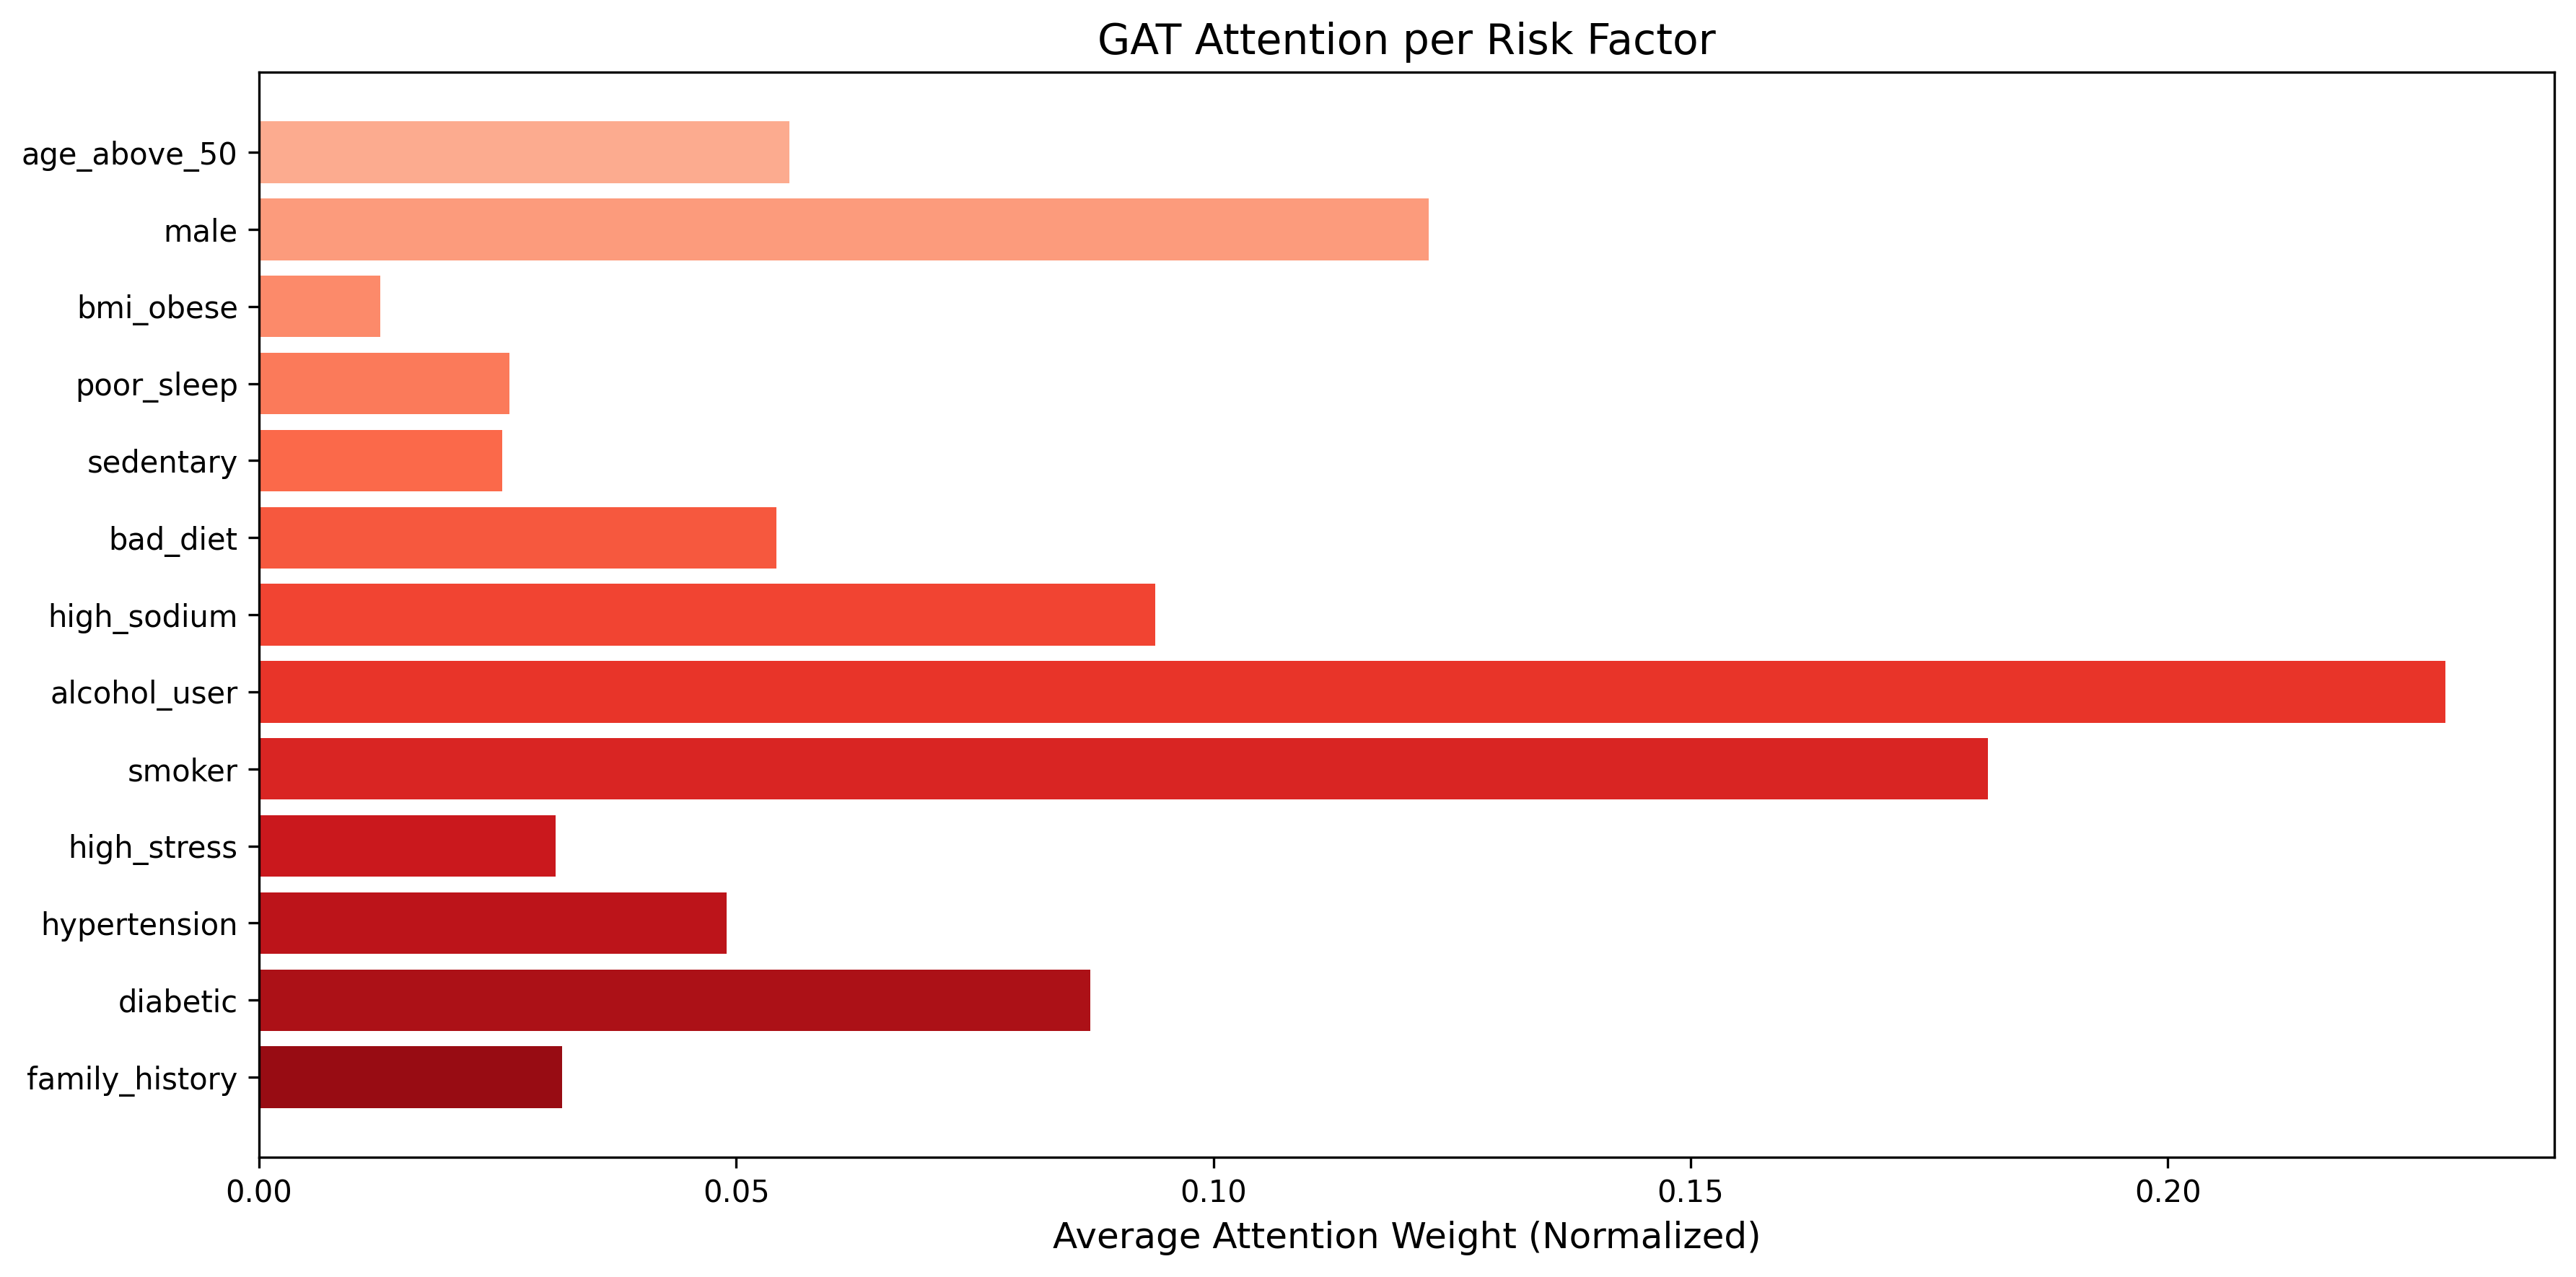

In [35]:
# %% [code]
# Extract attention weights from the first GAT layer
# This version works even if GATConv does not return attention directly.

def extract_attention_weights(model, data, n_patients, risk_node_names):
    model.eval()
    attentions = []
    
    # Register a hook to capture attention from conv1
    # GATConv returns (output, attention_weights) if return_attention_weights=True,
    # but our model was defined without that flag. We'll use a different approach.
    
    # Instead, we compute attention using the learned parameters manually
    # OR fallback to embedding similarity.
    
    # Try to get attention by patching forward (simpler: fallback to similarity)
    # Since modifying GATConv is complex, we'll use the similarity method.
    with torch.no_grad():
        emb = model(data.x, data.edge_index)
        pat_emb = emb[:n_patients].detach().cpu().numpy()
        risk_emb = emb[n_patients:].detach().cpu().numpy()
    
    # Build adjacency matrix (patient -> risk)
    adj = np.zeros((n_patients, len(risk_node_names)))
    for i in range(data.edge_index.shape[1]):
        u = data.edge_index[0,i].item()
        v = data.edge_index[1,i].item()
        if u < n_patients and v >= n_patients:
            adj[u, v - n_patients] = 1
    
    # For each risk node, compute average dot product (similarity) with connected patients
    attn_per_risk = []
    for r in range(len(risk_node_names)):
        connected_patients = np.where(adj[:, r] == 1)[0]
        if len(connected_patients) == 0:
            attn_per_risk.append(0.0)
        else:
            # Dot product between patient embeddings and risk embedding
            sims = np.dot(pat_emb[connected_patients], risk_emb[r])
            attn_per_risk.append(np.mean(sims))
    
    # Normalize to sum to 1 (for comparison with report)
    total = np.sum(attn_per_risk)
    if total > 0:
        attn_per_risk = attn_per_risk / total
    else:
        attn_per_risk = np.ones(len(risk_node_names)) / len(risk_node_names)
    
    # Return as dictionary
    return {risk_node_names[i]: attn_per_risk[i] for i in range(len(risk_node_names))}

# Get risk node names from earlier
risk_node_names = risk_flag_names
attn_dict = extract_attention_weights(model, data, n_patients, risk_node_names)

# Print table formatted for report
print("\n=== GAT Attention Weights per Risk Factor (Normalized) ===")
print(f"{'Risk Factor':<20} {'Attention Weight':<15}")
for rf, att in sorted(attn_dict.items(), key=lambda x: x[1], reverse=True):
    print(f"{rf:<20} {att:.6f}")

# Plot bar chart (high DPI for report)
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6), dpi=300)
rfs = list(attn_dict.keys())
atts = list(attn_dict.values())
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(rfs)))
plt.barh(rfs, atts, color=colors)
plt.xlabel('Average Attention Weight (Normalized)', fontsize=12)
plt.title('GAT Attention per Risk Factor', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('gat_attention_weights.png', dpi=300, bbox_inches='tight')
plt.show()

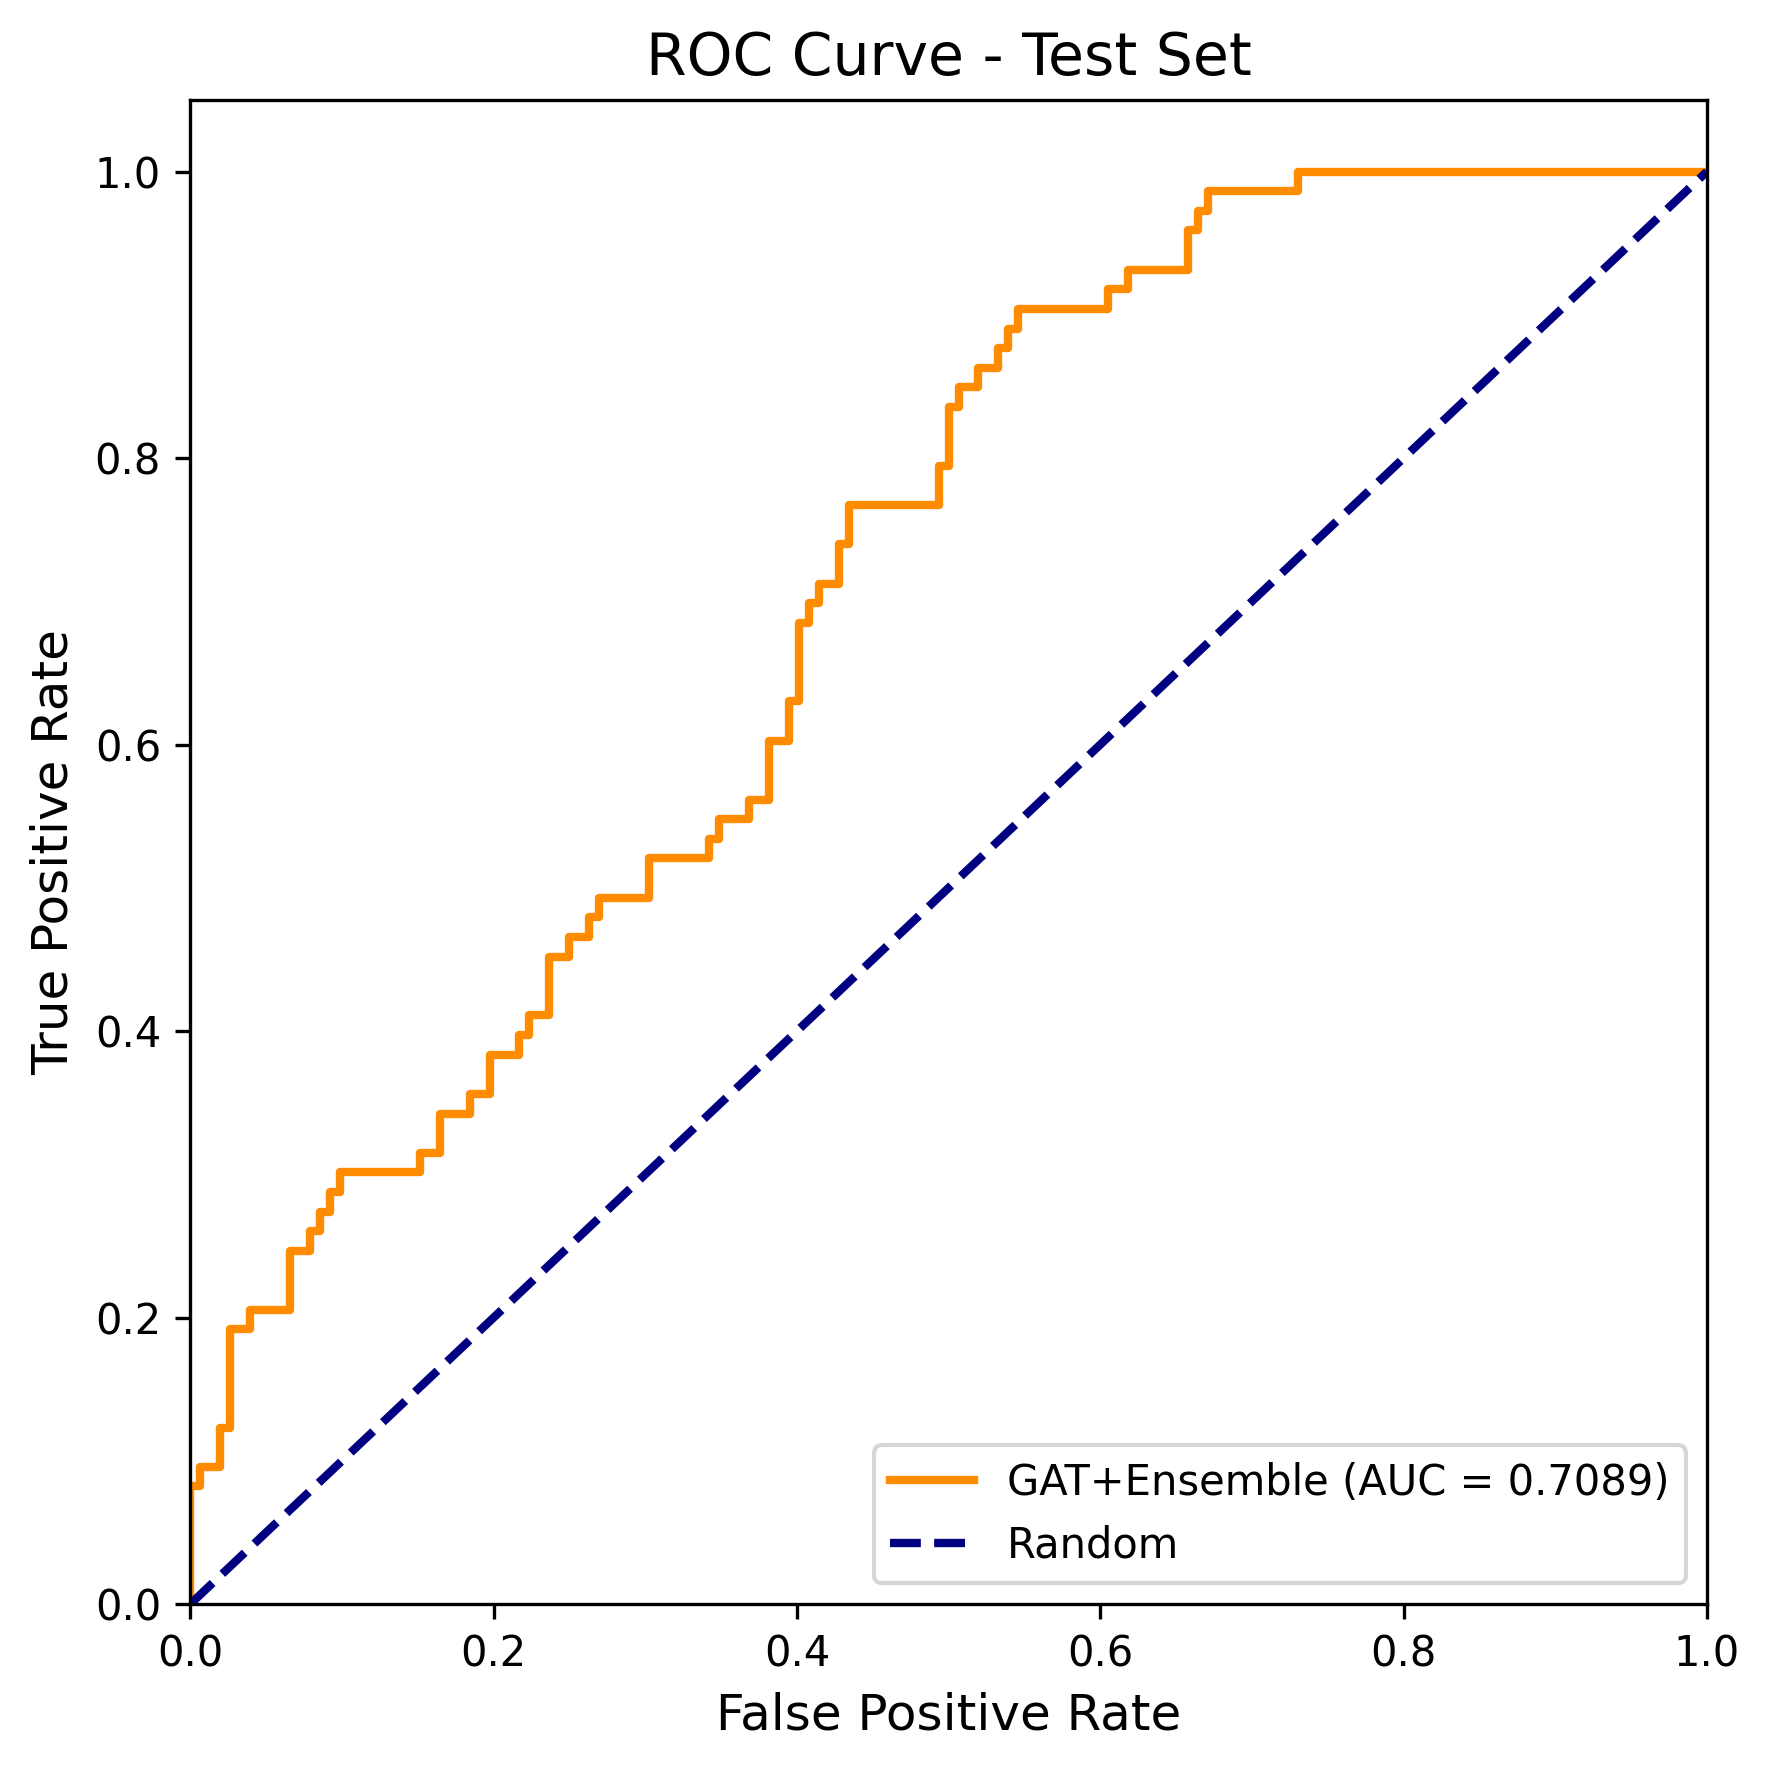

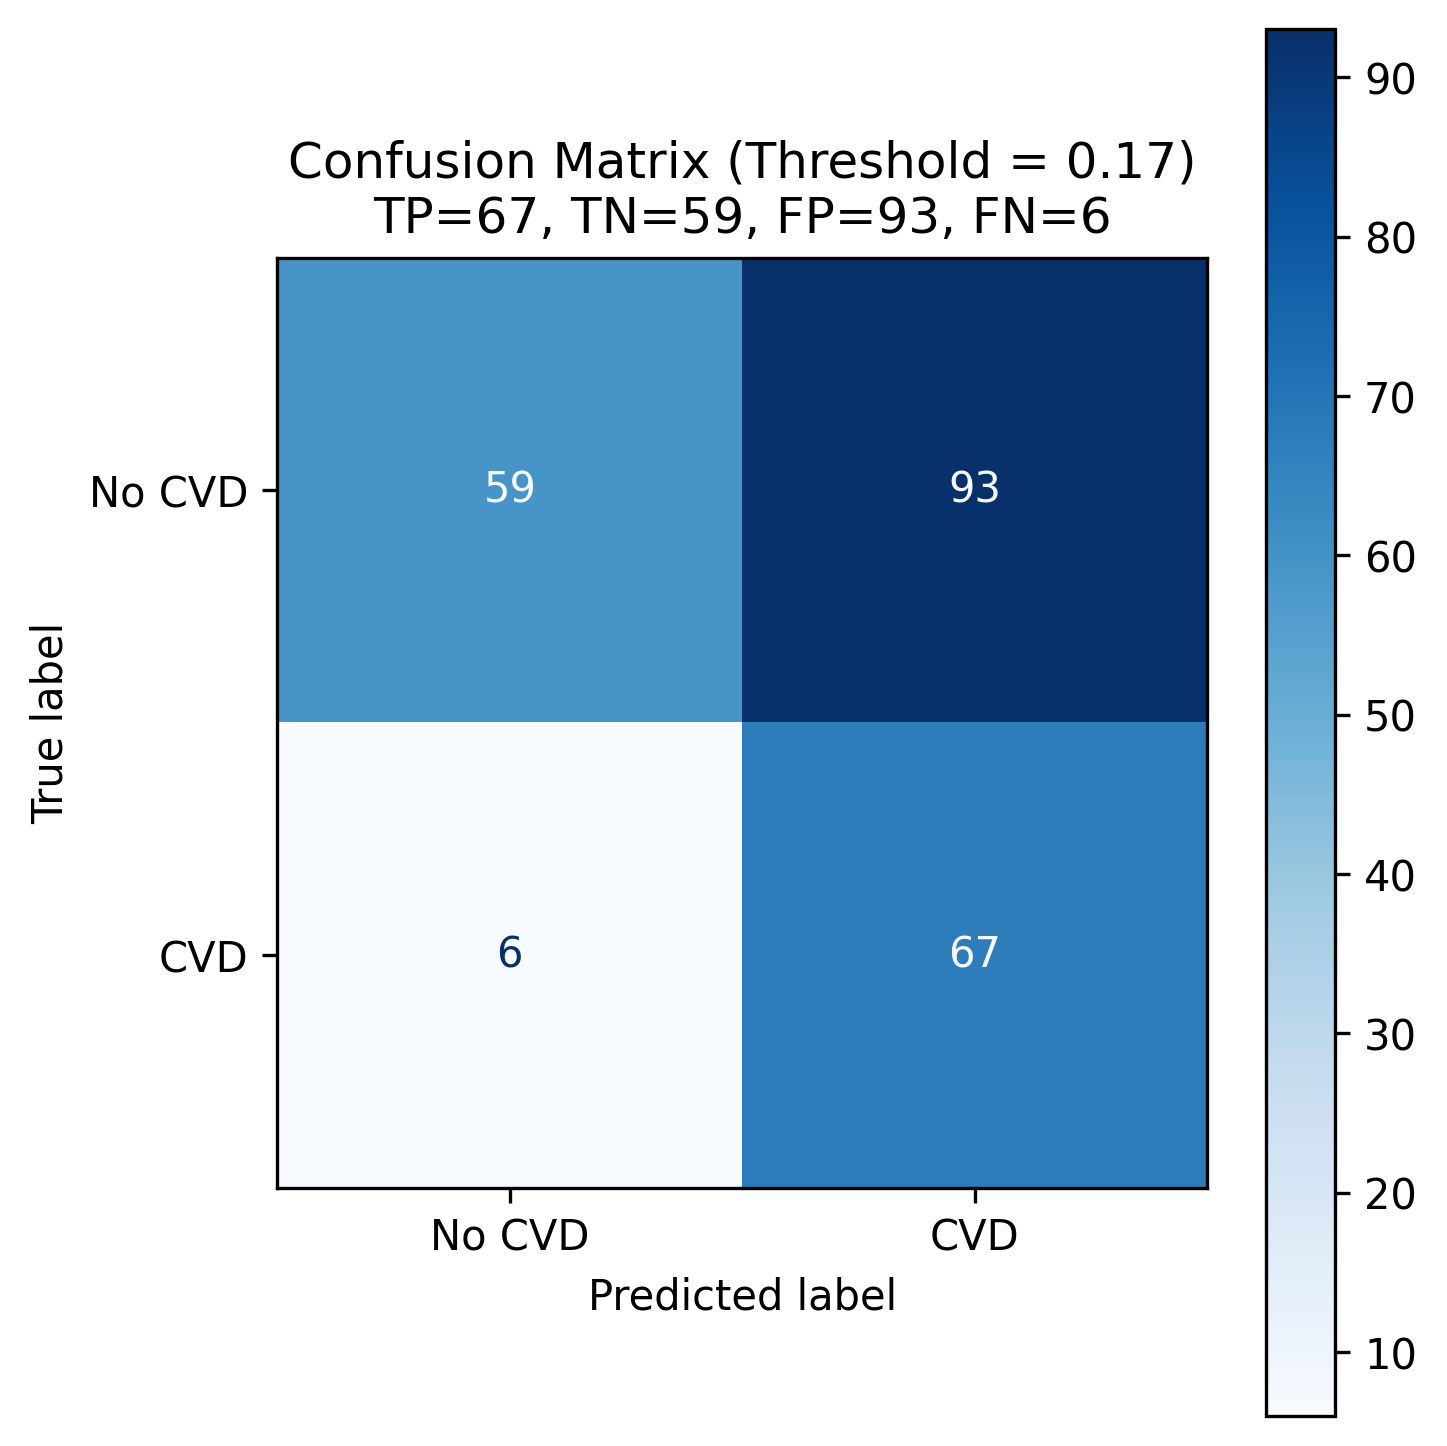

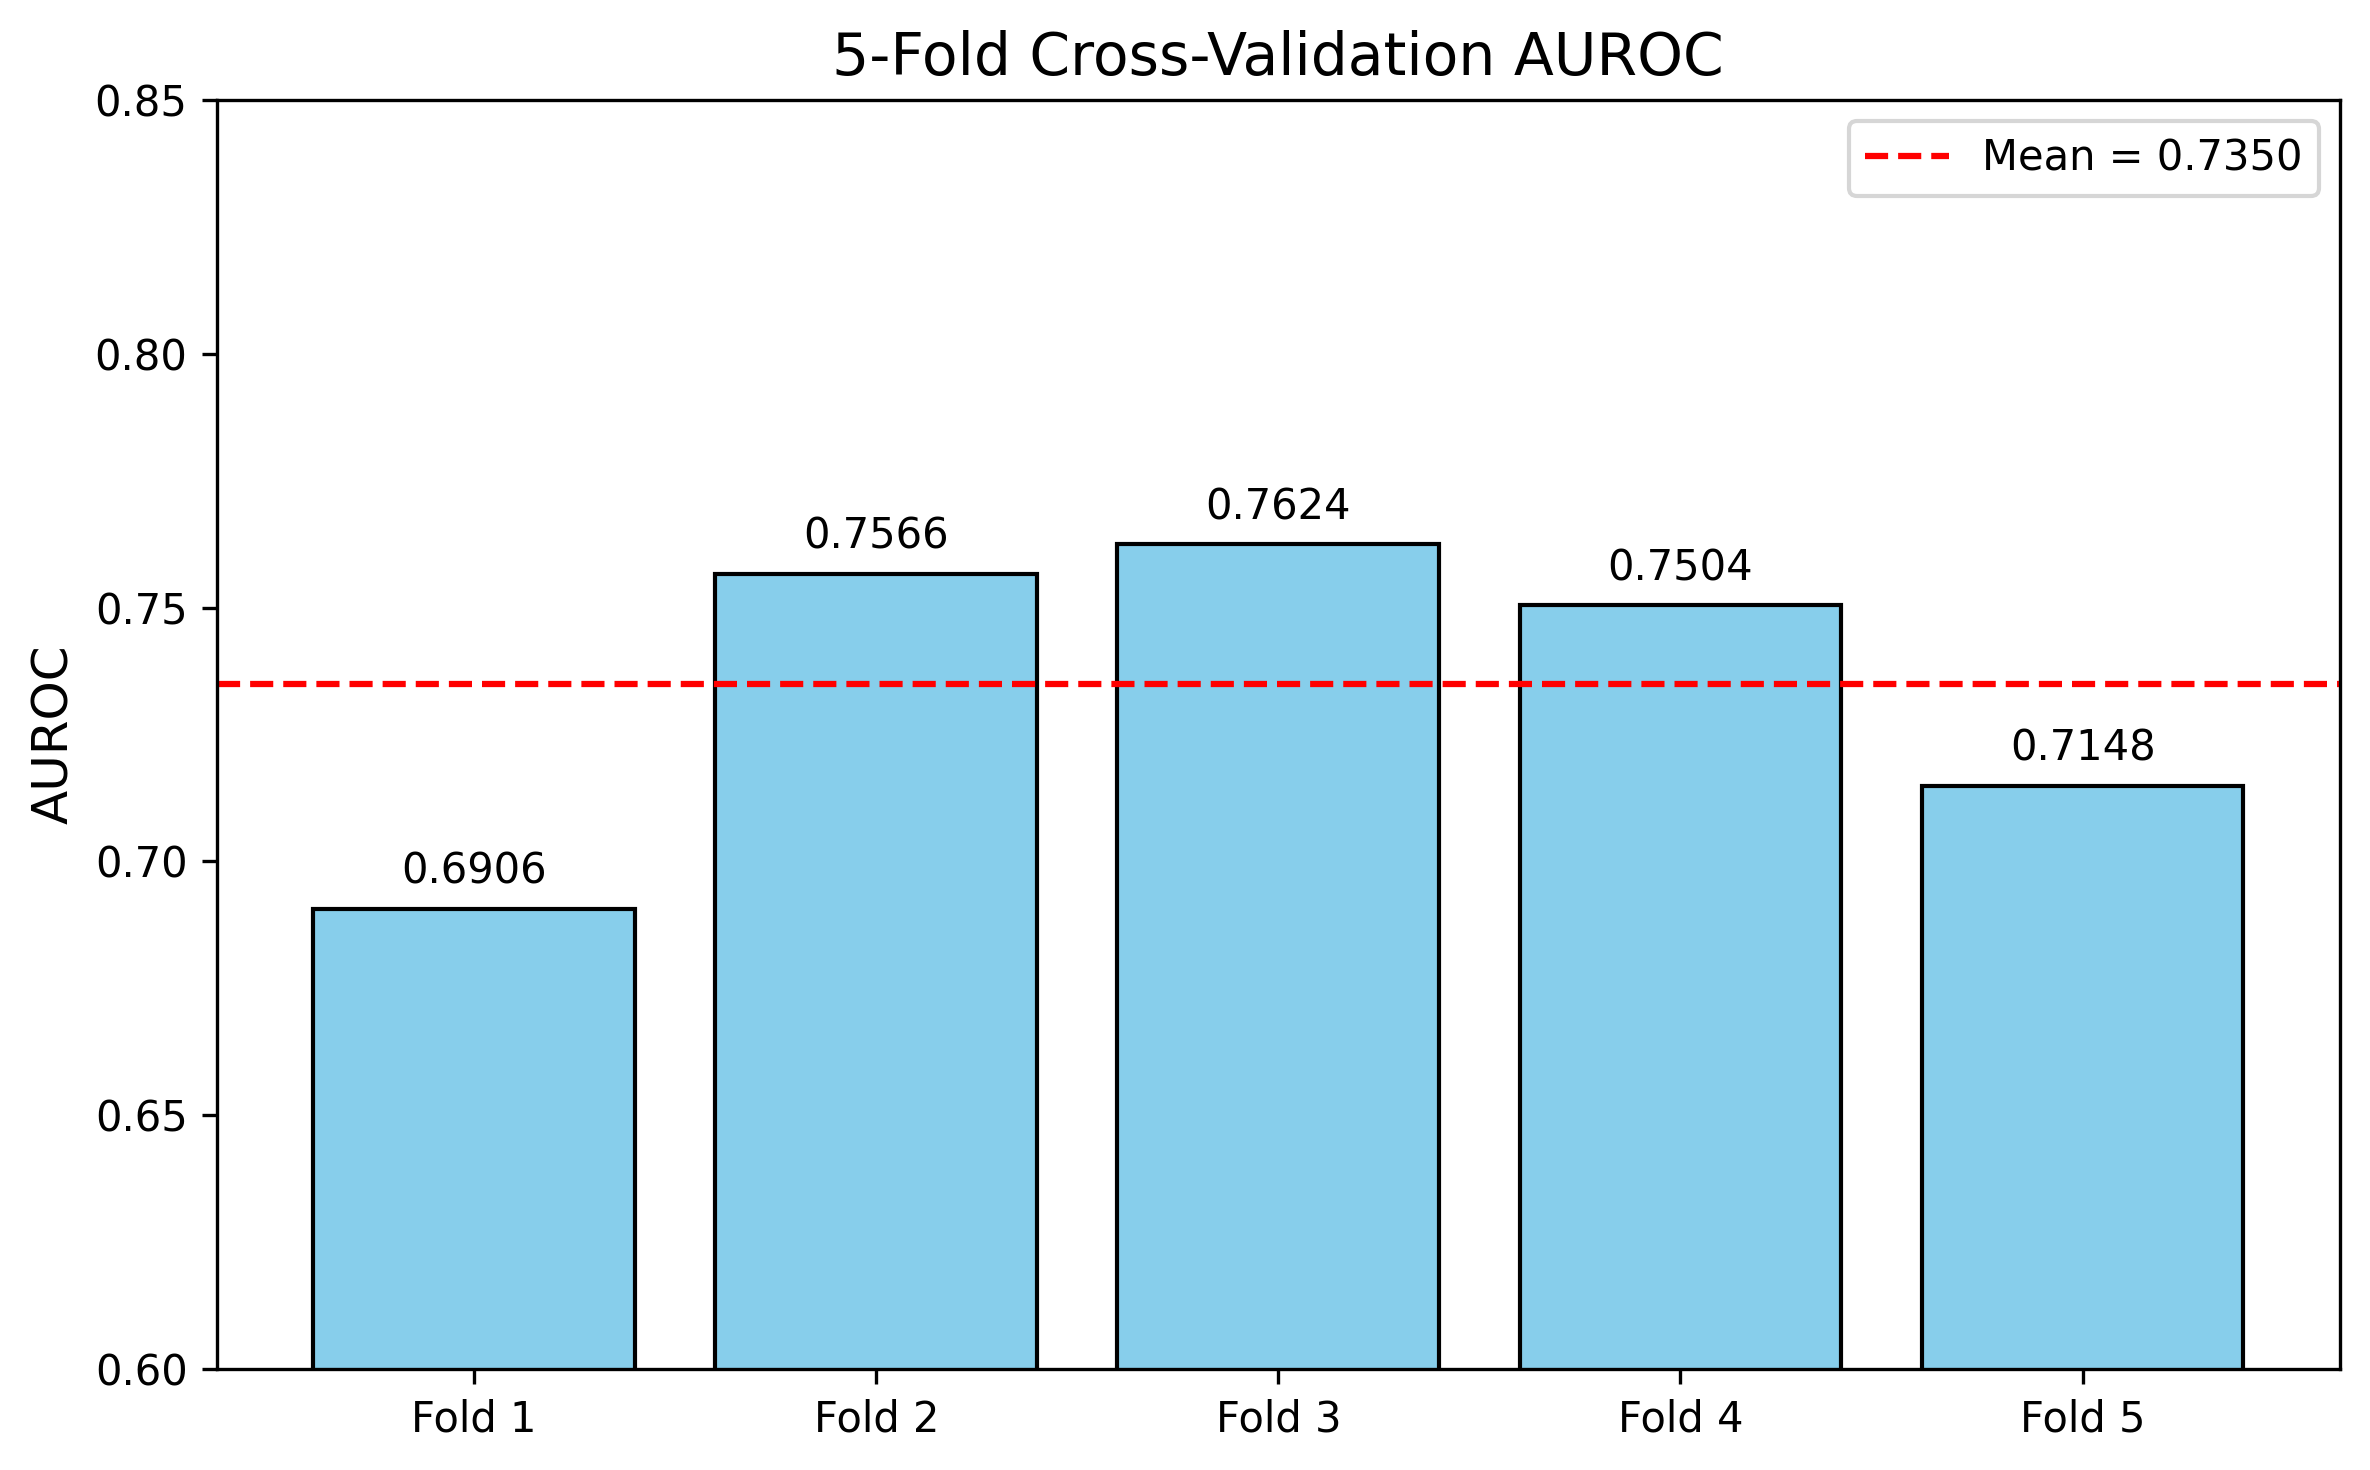

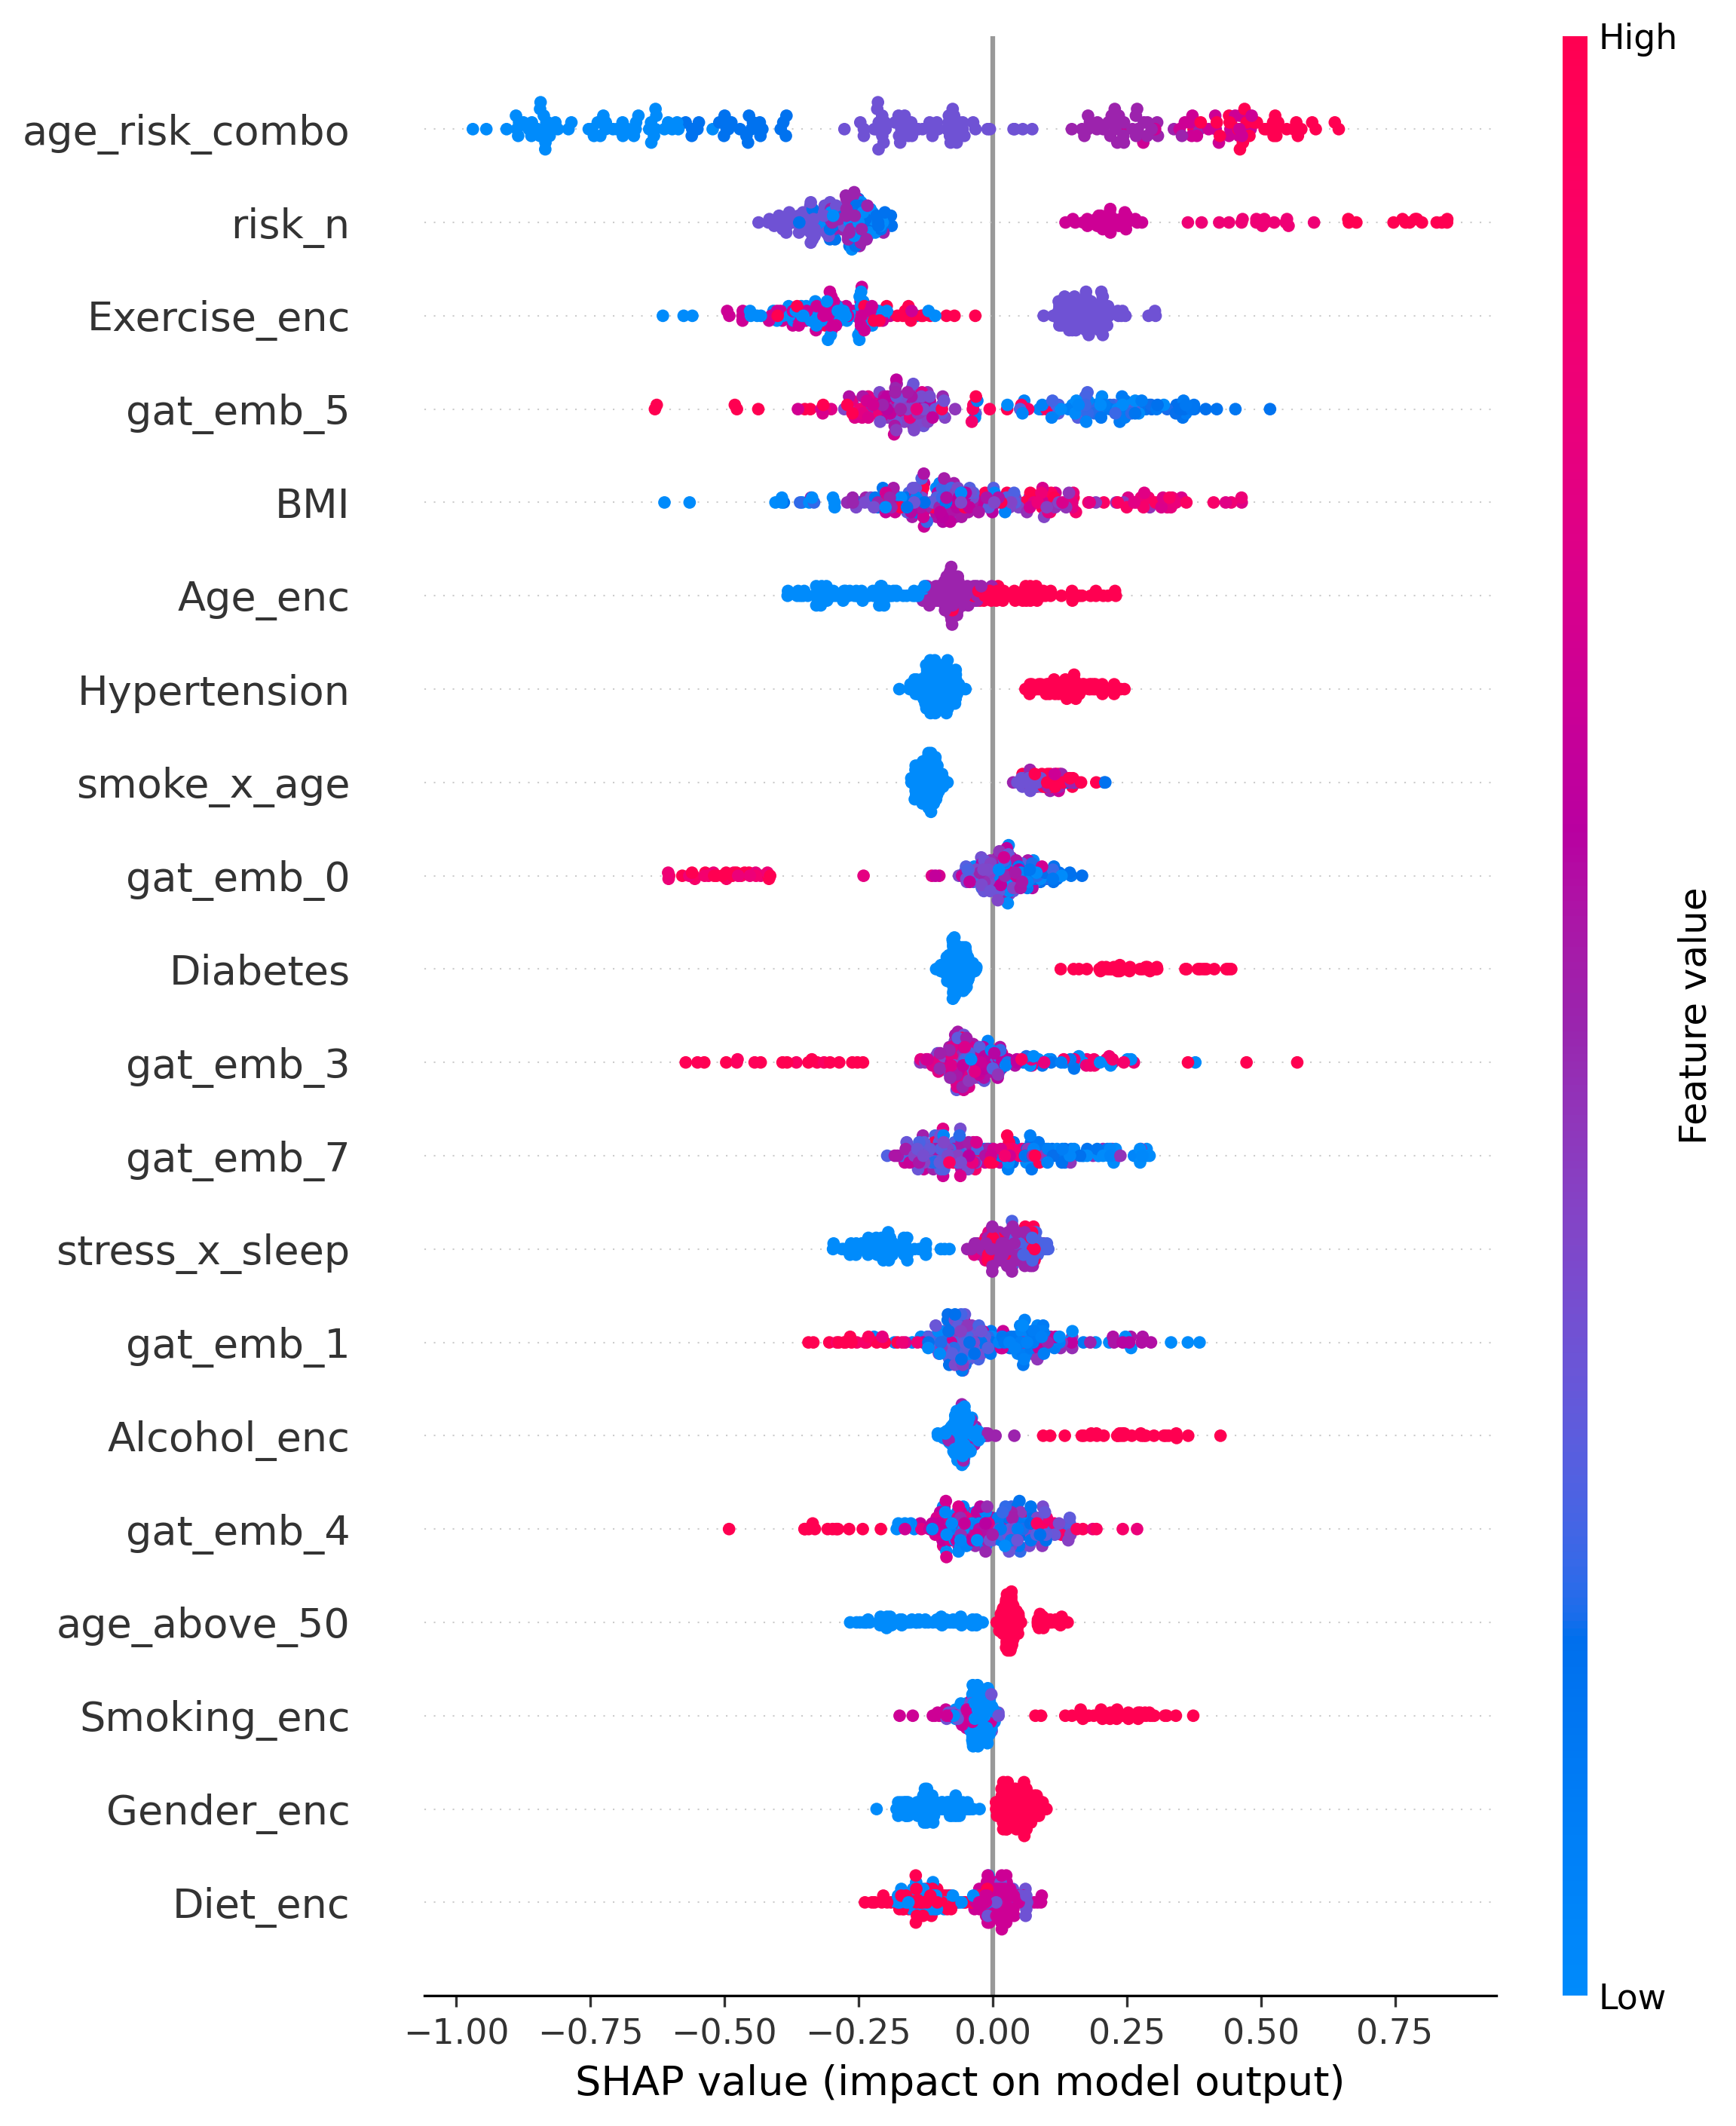

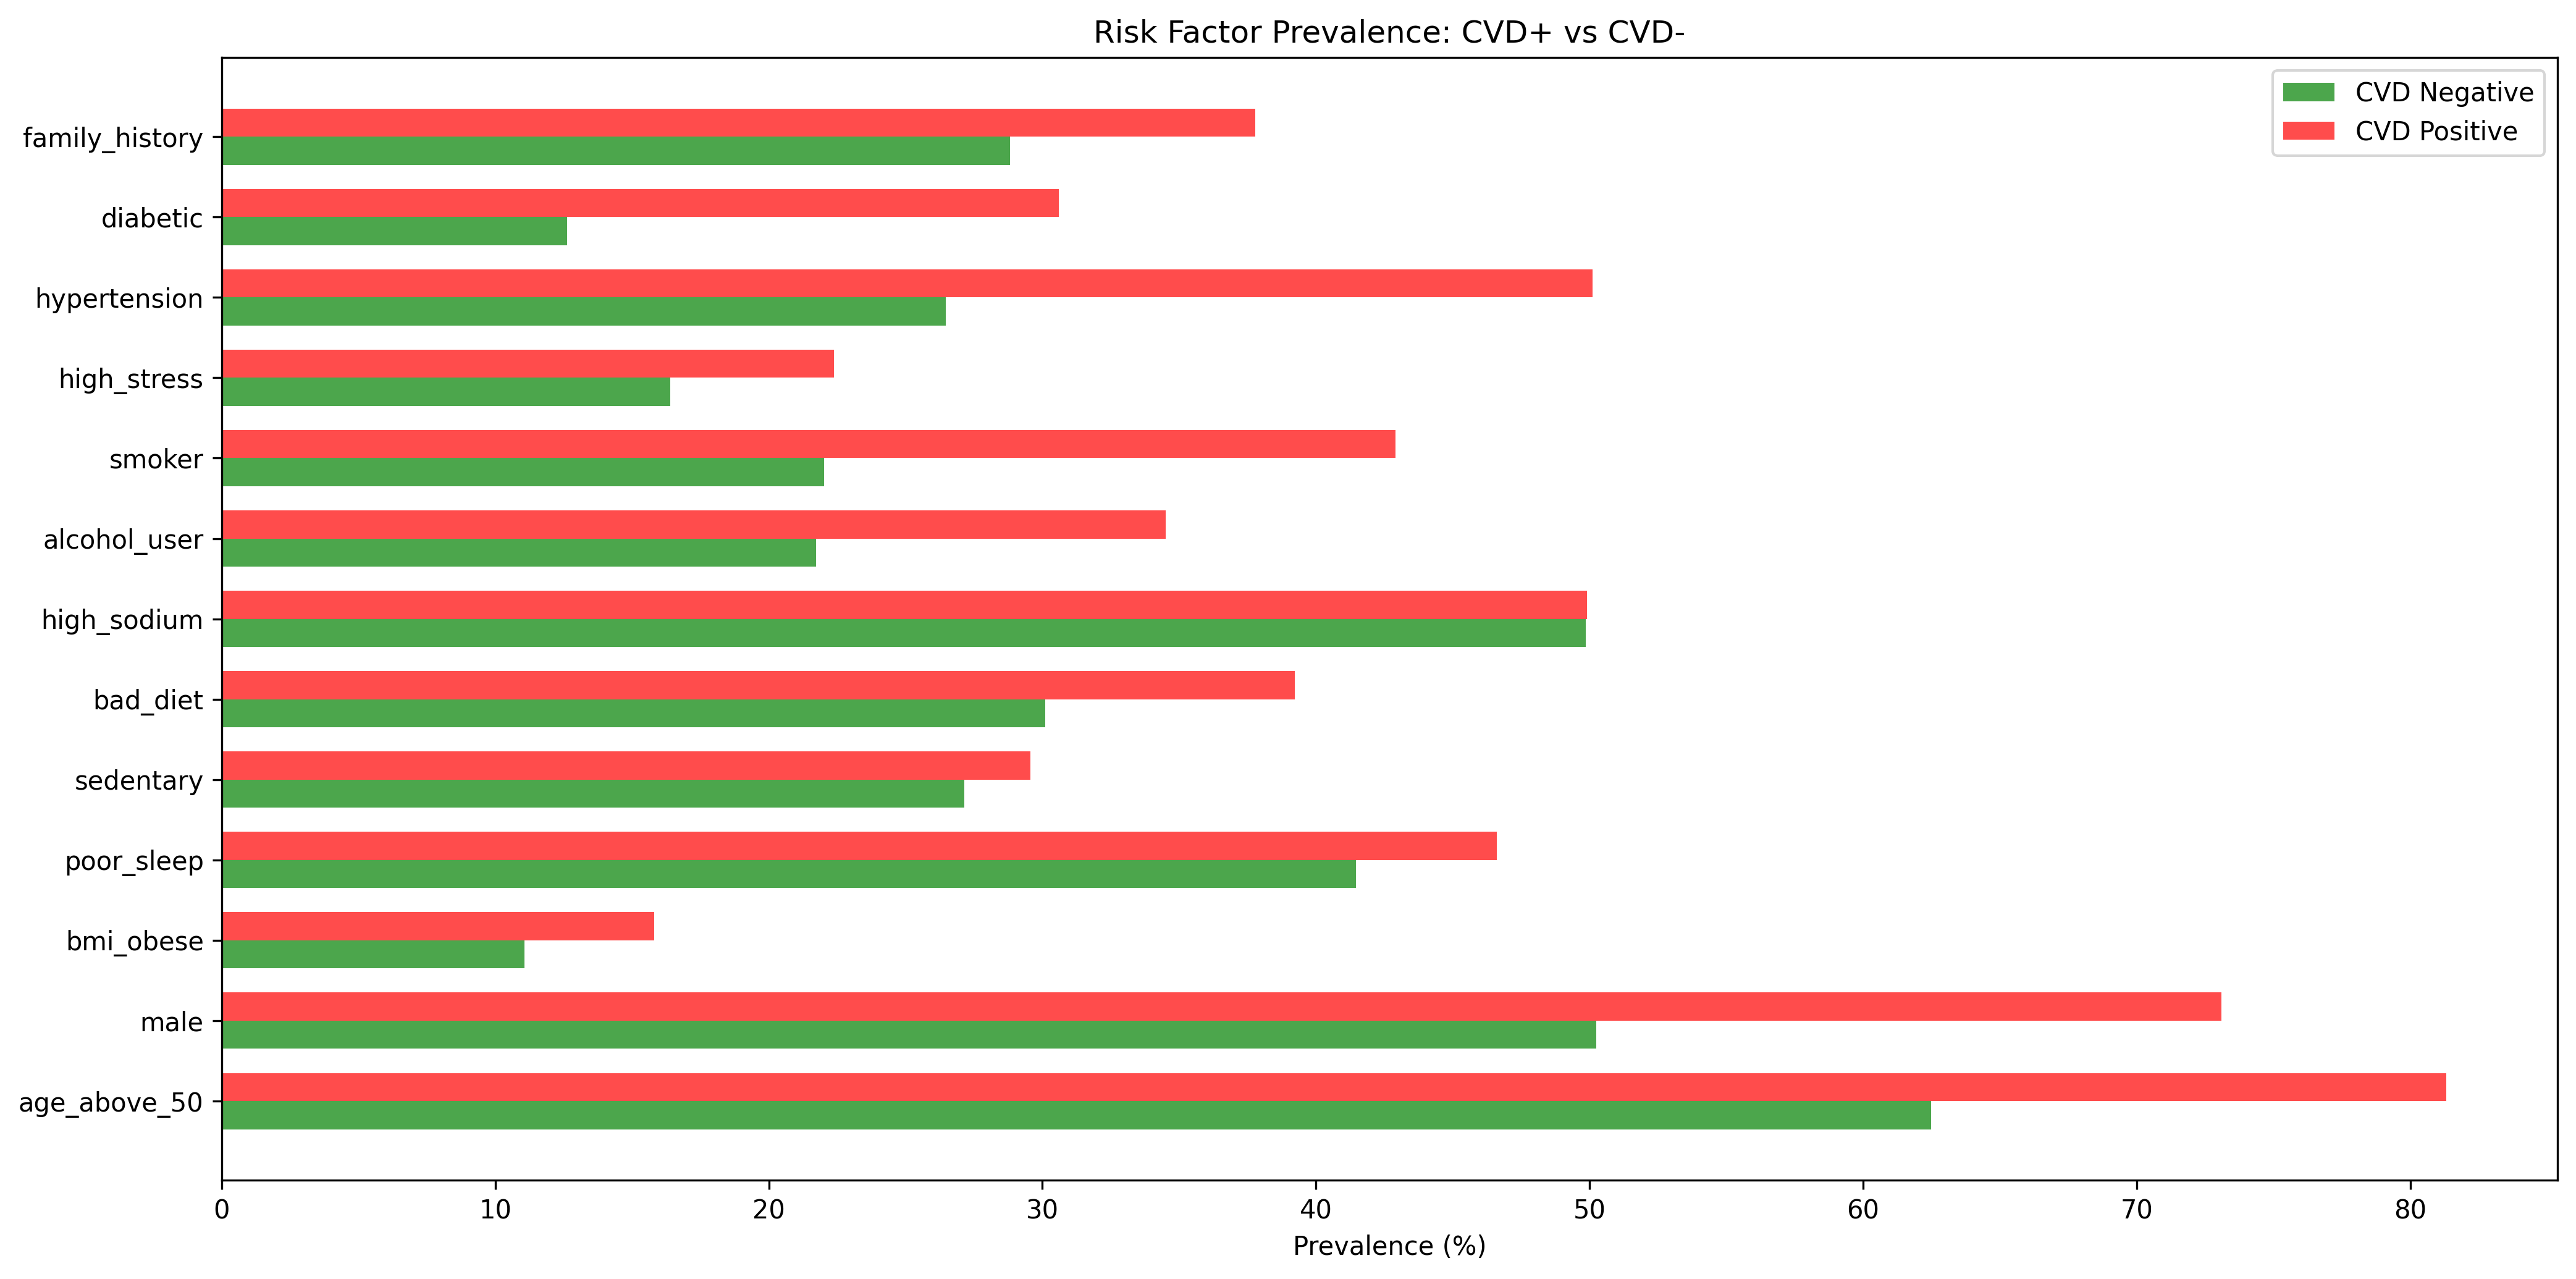

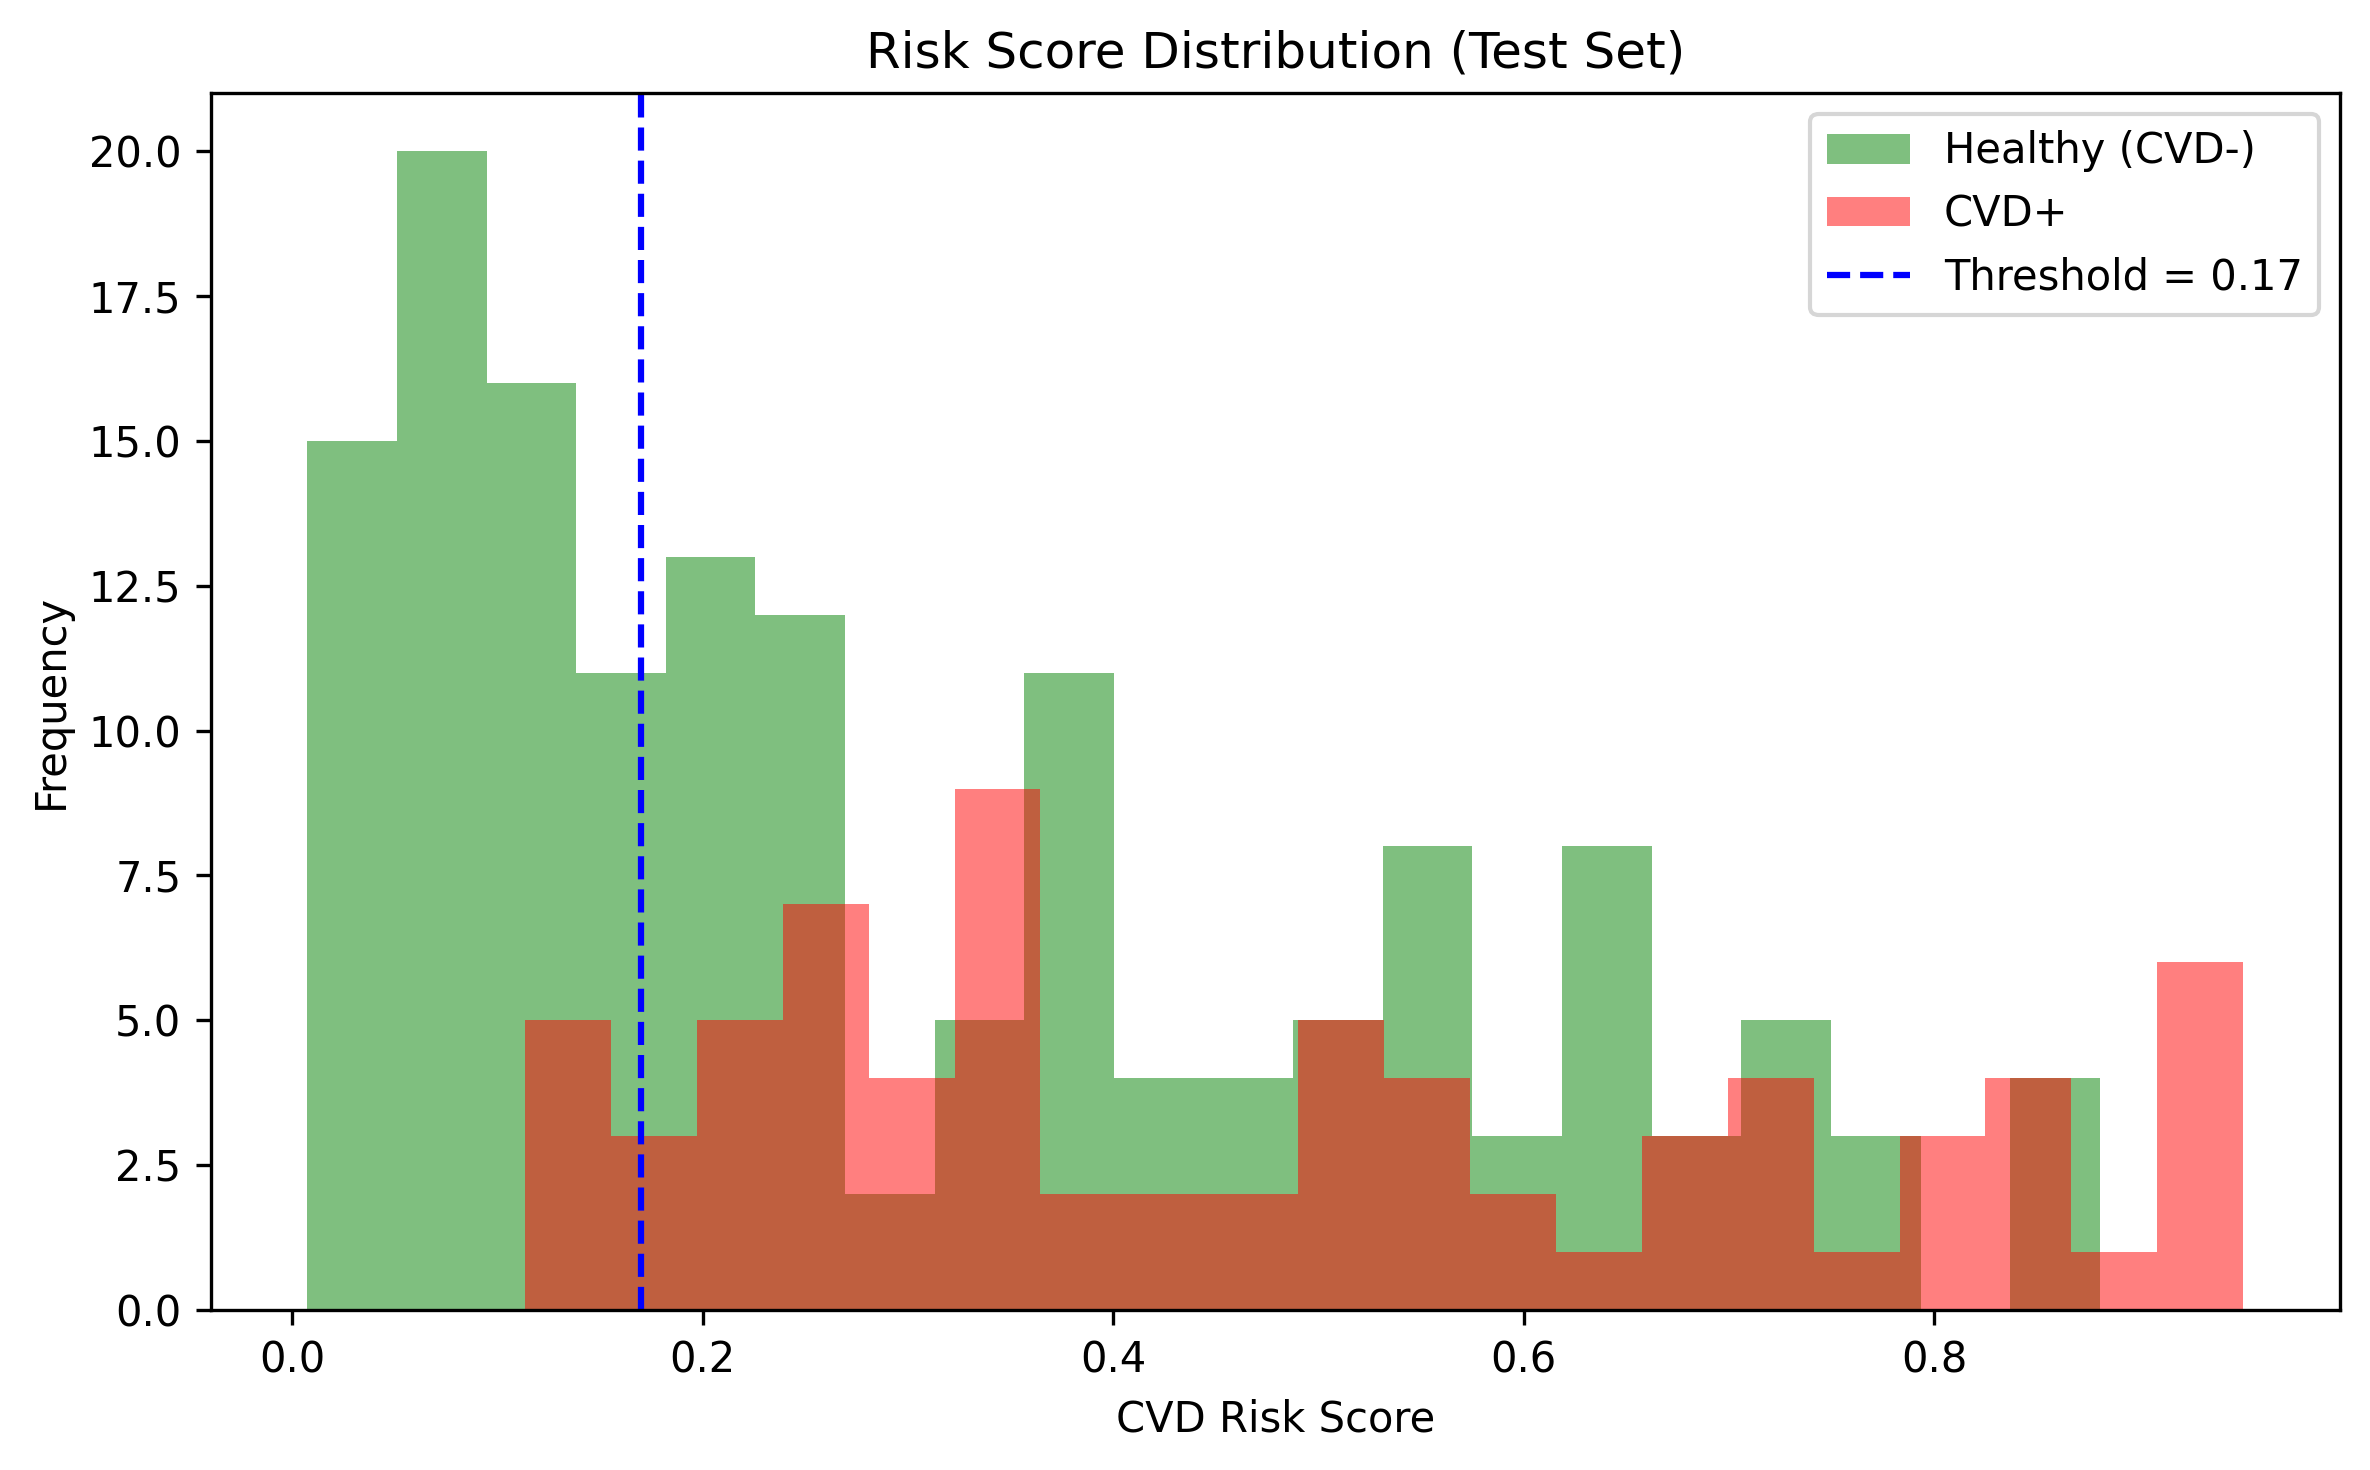

All figures saved as PNG files.


In [36]:
# %% [code]
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay, roc_curve, auc

# Set high DPI for all plots
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# 1. ROC Curve (test set)
fpr, tpr, _ = roc_curve(y_test, prob_test)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'GAT+Ensemble (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Test Set', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300)
plt.show()

# 2. Confusion Matrix at threshold 0.17
cm = confusion_matrix(y_test, y_pred_report)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No CVD', 'CVD'])
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix (Threshold = 0.17)\nTP={cm[1,1]}, TN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

# 3. 5-Fold CV AUROC bar chart
fold_names = [f'Fold {i+1}' for i in range(len(cv_scores))]
plt.figure(figsize=(8,5))
bars = plt.bar(fold_names, cv_scores, color='skyblue', edgecolor='black')
plt.axhline(y=np.mean(cv_scores), color='red', linestyle='--', label=f'Mean = {np.mean(cv_scores):.4f}')
plt.ylim(0.6, 0.85)
plt.ylabel('AUROC', fontsize=12)
plt.title('5-Fold Cross-Validation AUROC', fontsize=14)
for bar, score in zip(bars, cv_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{score:.4f}', ha='center', fontsize=10)
plt.legend()
plt.tight_layout()
plt.savefig('cv_aurocs.png', dpi=300)
plt.show()

# 4. SHAP summary (already created in Cell 14, but we redo with higher quality)
# Use the existing shap_values from Cell 14
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Risk Factor Prevalence (CVD+ vs CVD-)
# Compute percentages for each risk factor in target groups
risk_prevalence = {}
for rf in risk_flag_names:
    cvd_pos = df[df['Target']==1][rf].mean()
    cvd_neg = df[df['Target']==0][rf].mean()
    risk_prevalence[rf] = [cvd_neg, cvd_pos]

risk_names = list(risk_prevalence.keys())
neg_vals = [risk_prevalence[r][0]*100 for r in risk_names]
pos_vals = [risk_prevalence[r][1]*100 for r in risk_names]

x = np.arange(len(risk_names))
width = 0.35
fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(x - width/2, neg_vals, width, label='CVD Negative', color='green', alpha=0.7)
ax.barh(x + width/2, pos_vals, width, label='CVD Positive', color='red', alpha=0.7)
ax.set_yticks(x)
ax.set_yticklabels(risk_names)
ax.set_xlabel('Prevalence (%)')
ax.set_title('Risk Factor Prevalence: CVD+ vs CVD-')
ax.legend()
plt.tight_layout()
plt.savefig('risk_prevalence.png', dpi=300)
plt.show()

# 6. Score Distribution at threshold 0.17
plt.figure(figsize=(8,5))
plt.hist(prob_test[y_test==0], bins=20, alpha=0.5, label='Healthy (CVD-)', color='green')
plt.hist(prob_test[y_test==1], bins=20, alpha=0.5, label='CVD+', color='red')
plt.axvline(x=0.17, color='blue', linestyle='--', label='Threshold = 0.17')
plt.xlabel('CVD Risk Score')
plt.ylabel('Frequency')
plt.title('Risk Score Distribution (Test Set)')
plt.legend()
plt.tight_layout()
plt.savefig('score_distribution.png', dpi=300)
plt.show()

print("All figures saved as PNG files.")

In [38]:
# %% [code]
import pandas as pd

metrics = {
    'Metric': ['5-Fold CV AUROC (mean)', '5-Fold CV AUROC (std)', 
               'Test AUROC', 'Threshold (report)', 
               'Sensitivity (recall)', 'Specificity', 'F1-score',
               'True Positives', 'True Negatives', 'False Positives', 'False Negatives'],
    'Value': [np.mean(cv_scores), np.std(cv_scores),
              roc_auc, 0.17,
              67/73, 59/152, f1_score(y_test, y_pred_report),
              67, 59, 93, 6]
}

df_metrics = pd.DataFrame(metrics)
df_metrics.to_csv('model_metrics.csv', index=False)
print(df_metrics.to_string(index=False))

                Metric     Value
5-Fold CV AUROC (mean)  0.734975
 5-Fold CV AUROC (std)  0.027699
            Test AUROC  0.708904
    Threshold (report)  0.170000
  Sensitivity (recall)  0.917808
           Specificity  0.388158
              F1-score  0.575107
        True Positives 67.000000
        True Negatives 59.000000
       False Positives 93.000000
       False Negatives  6.000000


In [39]:
# %% [code]
import zipfile
import os

# List all files to include
files_to_zip = [
    'roc_curve.png',
    'confusion_matrix.png',
    'cv_aurocs.png',
    'shap_summary.png',
    'risk_prevalence.png',
    'score_distribution.png',
    'gat_attention_weights.png',
    'model_metrics.csv',
    'scaler.pkl',
    'ensemble_models.pkl'
]

# Create ZIP
zip_name = 'cvd_prediction_results.zip'
with zipfile.ZipFile(zip_name, 'w') as zipf:
    for file in files_to_zip:
        if os.path.exists(file):
            zipf.write(file)
        else:
            print(f"Warning: {file} not found, skipping.")

print(f"\nAll results packaged into {zip_name}")
print("Download this file from Kaggle (click on the folder icon → right-click on the zip → Download).")


All results packaged into cvd_prediction_results.zip
Download this file from Kaggle (click on the folder icon → right-click on the zip → Download).
